# Phase 2: Exploratory Data Analysis & Preprocessing
In this notebook, we will explore the `Crop Recommendation` and `Crop Production` datasets, handle any missing values, engineer the `Yield` feature, and prepare the data for Phase 3 (Model Building).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

# Set plotting style
sns.set_theme(style='whitegrid')

## 1. Load the Datasets

In [2]:
df_crop = pd.read_csv('../data/raw/Crop_recommendation.csv')
df_prod = pd.read_csv('../data/raw/crop_production.csv')

## 2. Explore Crop Recommendation Data
This dataset contains the optimal soil and weather conditions for different crops.

In [3]:
display(df_crop.head())
display(df_crop.info())
display(df_crop.describe())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


None

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
# Check for missing values
df_crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

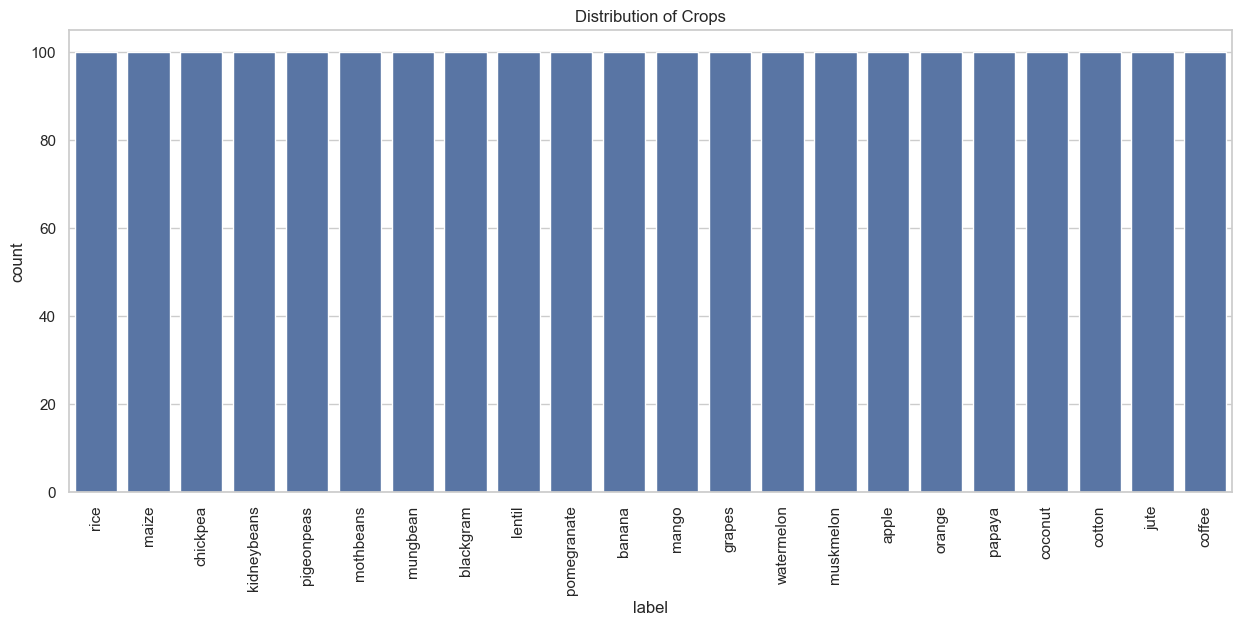

In [5]:
# Let's look at the distribution of the target variable (Crop Label)
plt.figure(figsize=(15, 6))
sns.countplot(data=df_crop, x='label')
plt.xticks(rotation=90)
plt.title('Distribution of Crops')
plt.show()

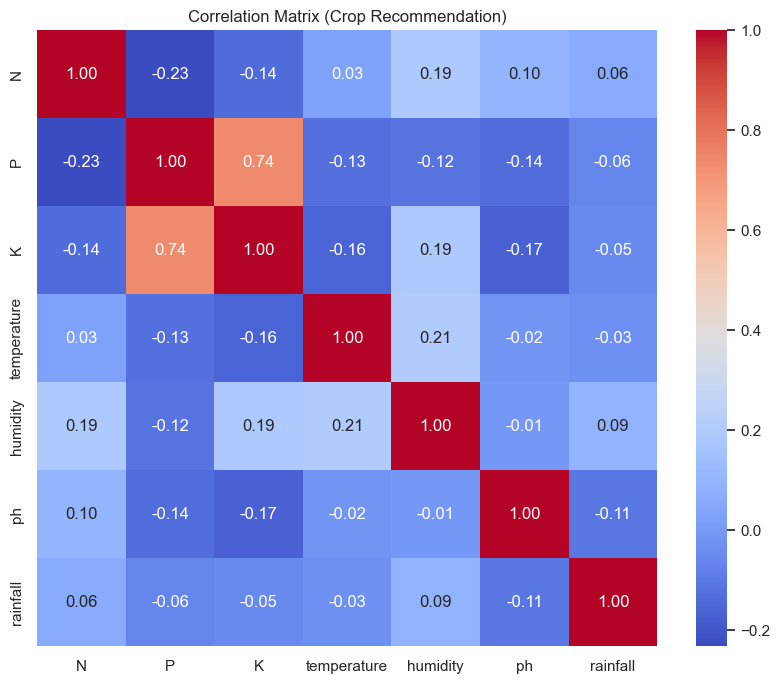

In [6]:
# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
numeric_cols = df_crop.select_dtypes(include=[np.number]).columns
sns.heatmap(df_crop[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Crop Recommendation)')
plt.show()

## 3. Explore & Preprocess Crop Production Data
This dataset contains historical production records. We need to handle missing values and calculate **Yield** (Production / Area).

In [7]:
display(df_prod.head())
display(df_prod.info())

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


None

In [8]:
# Check for missing values
df_prod.isnull().sum()

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

We have some missing values in the `Production` column. Since Production is critical for calculating Yield, we will drop rows with missing production data.

In [9]:
df_prod.dropna(subset=['Production'], inplace=True)
print('Null values after dropping:')
print(df_prod.isnull().sum())

Null values after dropping:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


In [10]:
# Feature Engineering: Calculate Yield
df_prod['Yield'] = df_prod['Production'] / df_prod['Area']
display(df_prod.head())

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


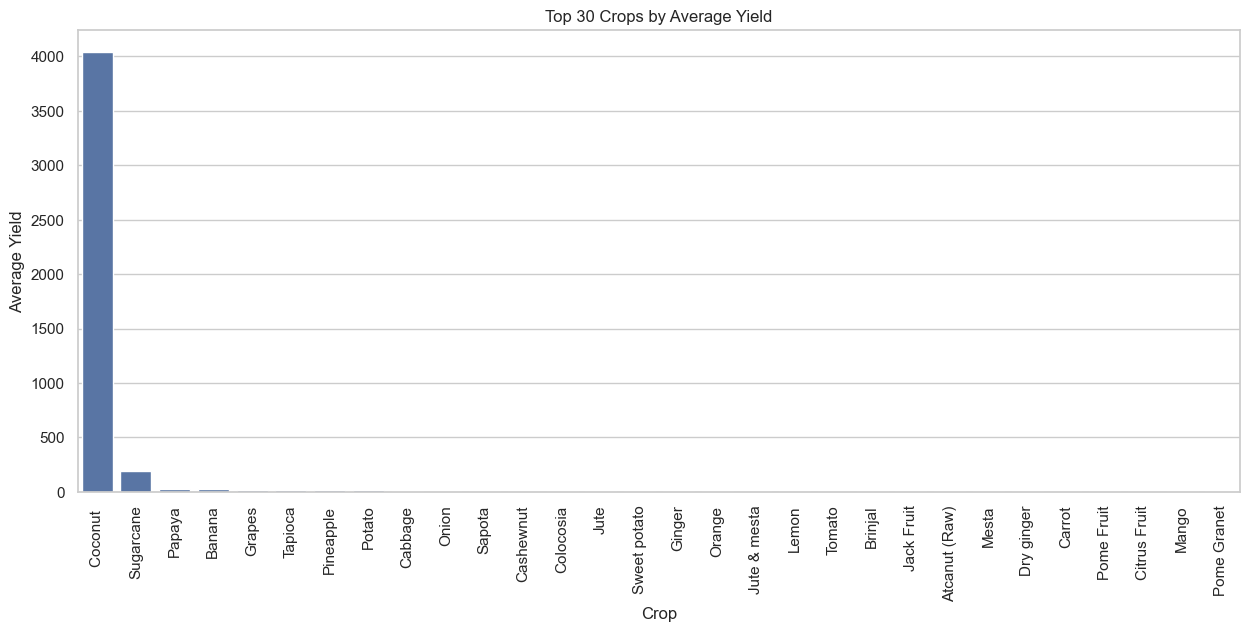

In [11]:
# Average yield per crop
plt.figure(figsize=(15, 6))
yield_per_crop = df_prod.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(30)
sns.barplot(x=yield_per_crop.index, y=yield_per_crop.values)
plt.xticks(rotation=90)
plt.title('Top 30 Crops by Average Yield')
plt.ylabel('Average Yield')
plt.show()

## 4. Save Processed Data
Now we save the cleaned datasets into `data/processed/` for model training and the profit engine.

In [12]:
os.makedirs('../data/processed', exist_ok=True)

df_crop.to_csv('../data/processed/Crop_recommendation_processed.csv', index=False)
df_prod.to_csv('../data/processed/crop_production_processed.csv', index=False)
print('Processed datasets saved successfully!')

Processed datasets saved successfully!
